In [1]:
%pip install scikit-learn matplotlib pandas graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


In [3]:
dataset = pd.read_csv('Iris.csv')
dataset.drop(columns=['Id'], inplace=True)

In [4]:
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print(dataset.isnull().sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['Species'] = le.fit_transform(dataset['Species'])  # type: ignore

In [7]:
dataset.sample(5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
51,6.4,3.2,4.5,1.5,1
44,5.1,3.8,1.9,0.4,0
67,5.8,2.7,4.1,1.0,1
6,4.6,3.4,1.4,0.3,0
139,6.9,3.1,5.4,2.1,2


In [8]:
dataset.shape

(150, 5)

In [9]:
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [10]:
X = dataset.drop(columns=['Species'])
y= dataset['Species']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [41]:
clf = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)

In [42]:
clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [43]:
y_pred = clf.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [45]:
# for i in range(1,11):
#     clf = DecisionTreeClassifier(criterion="gini", max_depth=i, random_state=42)
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict(X_test)
#     print(f"Max Depth: {i}, Accuracy: {accuracy_score(y_test, y_pred)}")

In [46]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

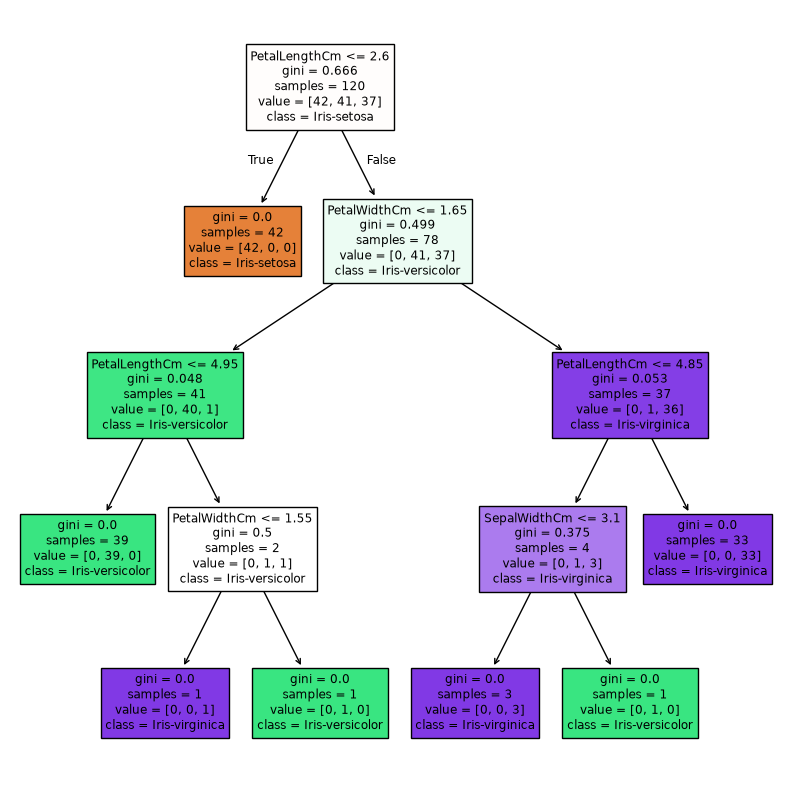

In [47]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=le.classes_,  # convert to strings
    filled=True
)
plt.show()

In [48]:
# Take Predictuion on Single Data Point
# Sepal Length, Sepal Width, Petal Length, Petal Width
single_data = [[6.9, 3.1, 4.9, 1.5]]
predicted_class = clf.predict(single_data)
print("Predicted class for single data point:", le.inverse_transform(predicted_class))

Predicted class for single data point: ['Iris-versicolor']


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


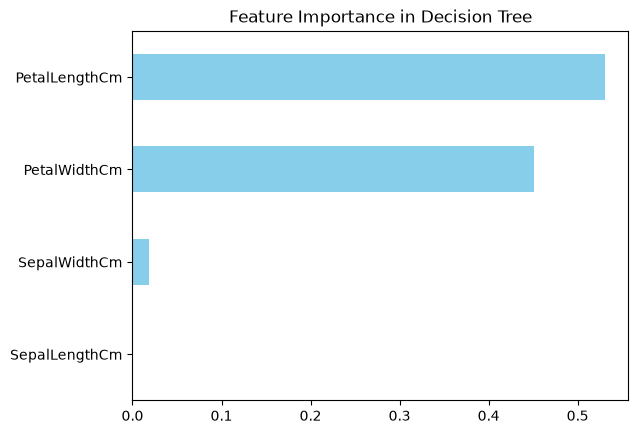

In [49]:
import pandas as pd

# Feature importance
feat_importance = pd.Series(clf.feature_importances_, index=X.columns)

# Plot
feat_importance.sort_values().plot(kind='barh', color="skyblue")
plt.title("Feature Importance in Decision Tree")
plt.show()

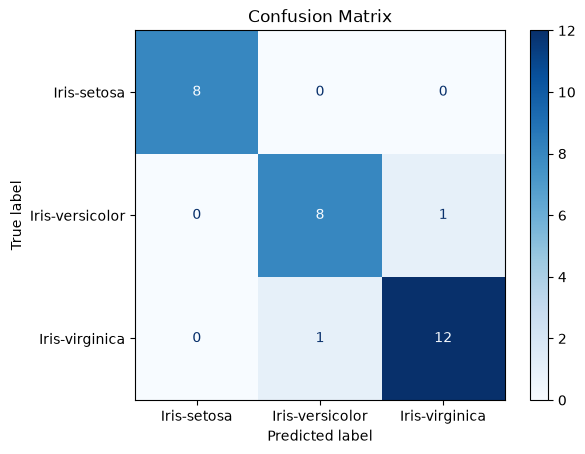

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=le.classes_,
                                        cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [51]:
import pickle
# Exporting the trained model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(clf, f)